# Californa housing

This project is a school assignment containing a predictive modelling solution using Python's Scikit-learn machine learning modules. The notebook contains code, figures and result, and the decision brief is presented in a seperate pdf-file. 

## Classification Assignment

**Background:**
The client needs a tool to quickly assess new or un-analyzed areas. They have access to area features (geography, household composition, income levels, etc.) but not housing values. The goal is to rapidly answer: “Is this likely a high-value area?”

**Task:**
- Create a binary target high_value in historical data:
    - high_value = 1 if median_house_value is in the top 20%
    - high_value = 0 otherwise
- Train a model to predict high_value using only the X variables (e.g., median_income, geography, household features, ocean_proximity)
- Exclude median_house_value and high_value from the input features

**Purpose:**
Enable prioritization of areas and assessment of critical error types (e.g., missing a high-value area vs. false positives). The goal is not to predict exact prices, but to quickly flag areas likely to be high-value for resource allocation.

## Setup & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.dummy import DummyRegressor

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

df = pd.read_csv("data/housing.csv")

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Dataset Overview

In [2]:
print("Dataset shape:", df.shape)
print("---------------------------")
print("Columns:", df.columns)
print("---------------------------")

Dataset shape: (20640, 10)
---------------------------
Columns: Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')
---------------------------


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


#### Dataset summary
- The dataset includes 20,640 observations and 10 variables. 
- All numerical variables is of the type float64. 
- There is one categorical value: *ocean_proximity*.
- Target-varibale is *median_house_value*.

## Split & Preprocessing

- Dela datan i train och test.
- Klassificering: använd stratifierad split (stratify) så att klasserna fördelas rimligt i train/test.
- manage missing values on training data - fit imputer and apply on training data

### Preparing classification problem

Create a binary target *high_value*:
- high_value = 1 if median_house_value is in the top 20%
- high_value = 0 otherwise

In [ ]:
# 1. Compute the threshold
threshold = df["median_house_value"].quantile(0.8)
print("80th percentile threshold:", threshold)

# 2. Create the binary target
df["high_value"] = (
    df["median_house_value"] >= threshold
).astype(int)

# 3. Checking class balance
df["high_value"].value_counts(normalize=True)

80th percentile threshold: 290000.0


high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64

### Defining X and y

In [ ]:
# 4. Define X and y

X_full = df.drop(["median_house_value", "high_value"], axis=1)                  
y_full = df["high_value"]

print("X:", X_full.shape, "y:", y_full.shape)

X: (20640, 9) y: (20640,)


### Train/test-split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print("Train shape \n "
    "x:", X_train.shape,
    "y:", y_train.shape)
print("Test shape \n "
    "x:", X_test.shape,
    "y:", y_test.shape)

Train shape 
 x: (16512, 9) y: (16512,)
Test shape 
 x: (4128, 9) y: (4128,)


### Sanity check

In [8]:
print(y_train.mean())
print(y_test.mean())

0.2000968992248062
0.2000968992248062


### Dataset overview - *on train*

In [12]:
display(X_train.describe().T)

,count,mean,std,min,25%,50%,75%,max
longitude,16512.0,-119.583568,2.004472,-124.3500,-121.8100,-118.5100,-118.010000,-114.3100
latitude,16512.0,35.648519,2.141321,32.5400,33.9400,34.2600,37.720000,41.9500
housing_median_age,16512.0,28.677628,12.572125,1.0000,18.0000,29.0000,37.000000,52.0000
total_rooms,16512.0,2624.633236,2155.292508,2.0000,1443.0000,2119.0000,3131.250000,39320.0000
total_bedrooms,16337.0,535.580217,417.478704,1.0000,295.0000,433.0000,645.000000,6445.0000
population,16512.0,1418.941315,1134.641808,3.0000,784.0000,1159.0000,1719.000000,35682.0000
households,16512.0,497.385719,379.126925,1.0000,279.0000,408.0000,602.000000,6082.0000
median_income,16512.0,3.869541,1.895598,0.4999,2.5658,3.5391,4.739375,15.0001


### Missing Values - on *train*

In [ ]:
print("Missning values per column:")
print(X_train.isna().sum())

Missning values per column (train):
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        175
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64


In [11]:
print("Missning values per column (%):")
X_train.isnull().sum() / len(df) * 100

Missning values per column (%):


longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        0.847868
population            0.000000
households            0.000000
median_income         0.000000
ocean_proximity       0.000000
dtype: float64

There are 175, about 0.85 %, missing values in *total_bedrooms*. Missing values will be managed with SimpleImputer, median imputation, in scikit-learn as a step in the pipeline. This method will be used as it:
- avoids leakage, imputation will only be learned from training data
- works inside the pipeline, and automatically applied to test data
- keeps preprocessing consistent

## EDA (on *train_set*)

### Class distribution of target

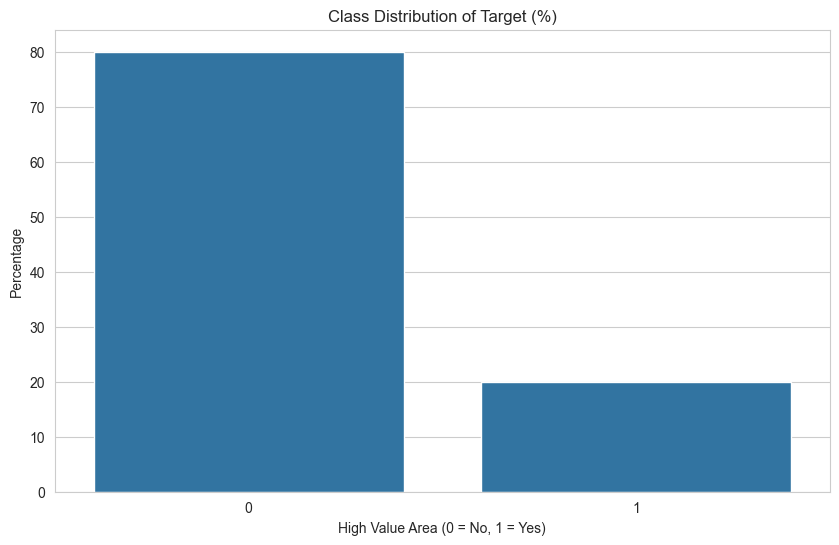

In [35]:
class_dist = y_train.value_counts(normalize=True) * 100

sns.barplot(
    x=class_dist.index,
    y=class_dist.values
)
plt.ylabel("Percentage")
plt.xlabel("High Value Area (0 = No, 1 = Yes)")
plt.title("Class Distribution of Target (%)")
plt.show()

- An 80/20 distribution show a mild imbalance in the dataset
- The meassure accuracy can alone be missleadning
- Precision, recall and F1 will matter

### Correlation with target

How strongly does the numerical features separate high-value vs low-value areas?

In [ ]:
train_with_target = X_train.copy()
train_with_target["median_house_value"] = y_train

corr_with_target = (
    train_with_target
    .drop("ocean_proximity", axis=1)
    .corr()["median_house_value"]
    .sort_values(ascending=False)
)

print(corr_with_target)

median_house_value    1.000000
median_income         0.544130
housing_median_age    0.101761
total_rooms           0.089778
households            0.017756
total_bedrooms        0.009693
longitude            -0.057283
population           -0.059665
latitude             -0.062696
Name: median_house_value, dtype: float64


### Highest correlating feature vs High Value Area

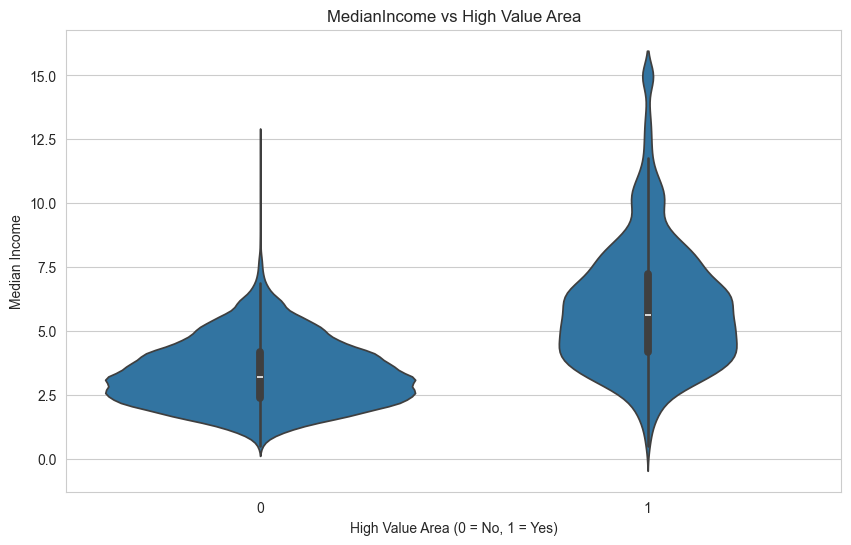

In [ ]:
sns.violinplot(
    x=y_train, 
    y=X_train["median_income"] 
   )
plt.xlabel("High Value Area (0 = No, 1 = Yes)")
plt.ylabel("Median Income")
plt.title("Median Income vs High Value Area")
plt.show()

- High value areas (class 1) has a clearly higher median income
- The medians are well seperated
- There are high-income outliers in both groups

**Conclusion:** *median_income* seem to be a strong predictor of *high_value*

### Geographical distribution of high-value areas
Where are high-value areas located geographically?

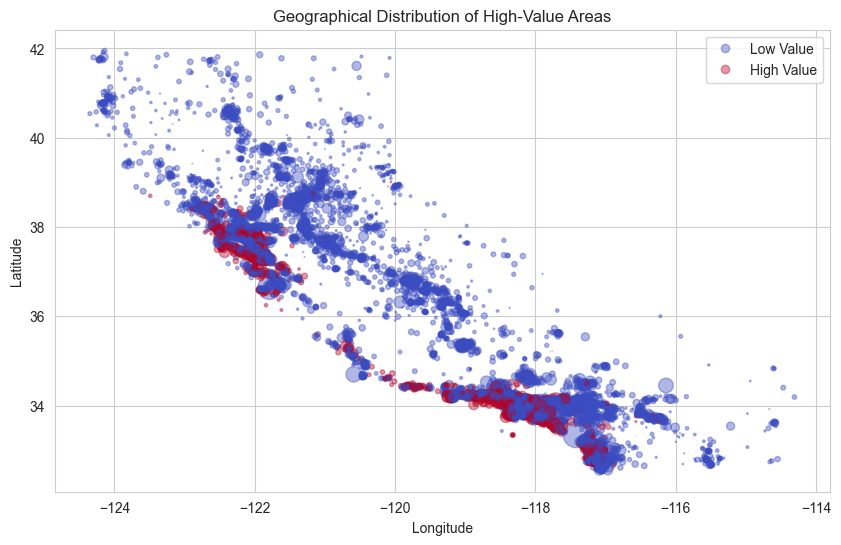

In [39]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    X_train["longitude"],
    X_train["latitude"],
    s=X_train["population"]/100,
    c=y_train,
    cmap="coolwarm",
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of High-Value Areas")

plt.legend(handles=scatter.legend_elements()[0],
           labels=["Low Value", "High Value"])

plt.show()

- High value areas (class 1) are primarily concentrated to the coast line and centered to urban areas. 
- Lower-value areas dominate inland. 
- Geographical position seems to have a strong impact on price variation. 

### Ocean Proximity
How does ocean proximity affect probability of being high-value (top 20%)?

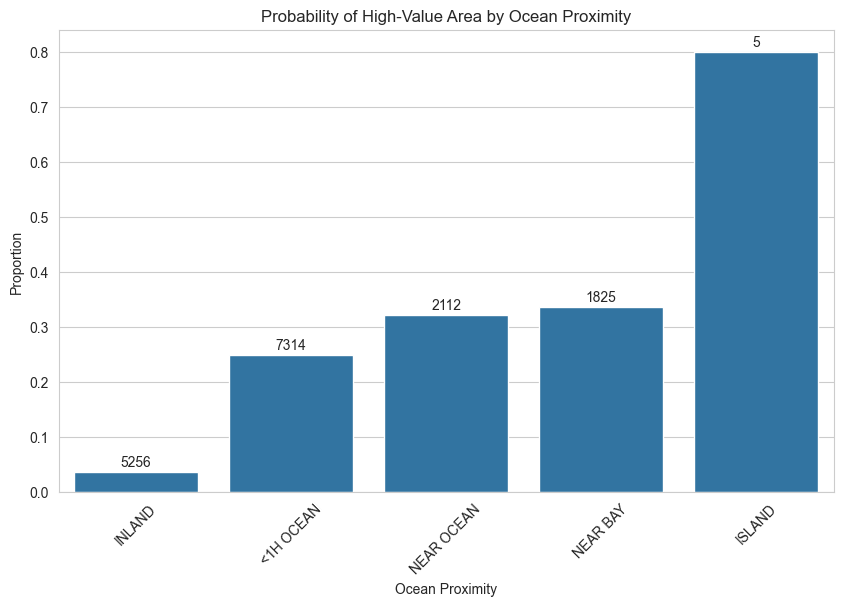

In [45]:
train_with_target = X_train.copy()
train_with_target["high_value"] = y_train

ocean_high_value_rate = (
    train_with_target
    .groupby("ocean_proximity")["high_value"]
    .mean()
    .sort_values()
)

counts = train_with_target["ocean_proximity"].value_counts()

ax = sns.barplot(
    x=ocean_high_value_rate.index,
    y=ocean_high_value_rate.values
)

plt.ylabel("Proportion")
plt.xlabel("Ocean Proximity")
plt.xticks(rotation=45)
plt.title("Probability of High-Value Area by Ocean Proximity")

for i, category in enumerate(ocean_high_value_rate.index):
    count = counts[category]
    proportion = ocean_high_value_rate[category]
    
    ax.text(
        i,                      
        proportion + 0.01,      
        count,           
        ha="center"
    )

plt.show()

- Inland areas have about 5% high-value rate 
- <1H from ocean areas have about 25% high-value rate
- Near ocean areas have slightly 30% high-value rate
- Near bay area also have slightly over 30% high-value rate
- Island area have 80% high-value rate.

A strong location effect is detected, however island obervations are much more rare than other categories. 

## Unsupervised learning (PCA or KMeans)

Ledningen vill inte bara ha en modell – de vill också förstå om det finns naturliga grupper av områden i datan. Om sådana grupper finns kan det hjälpa till att:
segmentera områden (t.ex. “typområden” som liknar varandra),
upptäcka ovanliga områden (avvikare),
och få en enklare överblick över datan innan man tar beslut.

Uppdrag: 
Du ska därför undersöka om datan verkar innehålla struktur genom att använda PCA eller KMeans på ett rimligt urval av X-variabler (inte target).

Syfte - Att se om vi kan:
- sammanfatta datan i ett enklare “mönster” (PCA), eller
- hitta grupper av liknande områden (KMeans),
- och diskutera hur detta skulle kunna användas som beslutsstöd.

Krav:
- Implementera PCA eller KMeans
- Visa resultat (figur/tabell)
- Tolka kort: vad kan vi lära oss, och vad är osäkert?

Använd endast X-variabler (inte target), och motivera kort vilka features du inkluderade. Kom ihåg att metoderna är känsliga för skalning.

## Modelling

- Skapa en baseline.
- Träna minst två ytterligare modeller (totalt minst 3 inkl baseline).
- Jämför modellerna med en tydlig utvärderingsmetod (t.ex. cross-validation eller valideringsupplägg).

## Model optimization

- Välj en modell baserat på din jämförelse.
- Optimera den valda modellen med hyperparameter-tuning (t.ex. GridSearchCV). Du väljer själv vilka parametrar som är relevanta
- Beskriv kort vad du optimerade och vilken metric du optimerade mot.


## Evaluation on test result + recommendations

- Utvärdera din slutliga modell på testdata och rapportera resultatet.
- Välj minst en relevant metric och motivera valet:
- Regression: t.ex. MAE eller RMSE
- Klassificering: t.ex. F1 eller recall/precision
- Sammanfatta resultat tydligt (tabell rekommenderas).
- Skriv en kort rekommendation: vilken modell skulle du ta vidare och varför?